# Optional  Lab: 成本函数 
<figure>
    <center> <img src="../work/images/C1_W1_L3_S2_Lecture_b.png"  style="width:1000px;height:200px;" ></center>
</figure>



## 目标
在这个实验室中，你将：
- 你将实现并探索具有一个变量的线性回归的 `cost` 函数。



## Tools
在这个实验室中，我们将使用：
- NumPy，一个用于科学计算的流行库；
- Matplotlib，一个用于绘制数据的流行库；
- 以及本地目录中 lab_utils_uni.py 文件中的本地绘图例程。

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from lab_utils_uni import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl
plt.style.use('./deeplearning.mplstyle')

## 问题陈述

你想要一个可以根据房屋面积预测房价的模型。
让我们使用与上一个实验之前相同的两个数据点——一套 1000 平方英尺的房子售价为 30 万美元，一套 2000 平方英尺的房子售价为 50 万美元。


| Size (1000 sqft)     | Price (1000s of dollars) |
| -------------------| ------------------------ |
| 1                 | 300                      |
| 2                  | 500                      |


In [2]:
x_train = np.array([1.0, 2.0])           #(size in 1000 square feet)
y_train = np.array([300.0, 500.0])           #(price in 1000s of dollars)

## 计算成本

在这个任务中，“成本”一词可能有点令人困惑，因为数据是住房成本。在这里，成本是衡量我们的模型预测房屋目标价格的好坏程度的指标。“价格”一词用于住房数据。

单变量成本方程为：
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$

 
这里 
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{2}$$
  
- $f_{w,b}(x^{(i)})$是我们使用参数$w,b$对示例$i$的预测。
- $(f_{w,b}(x^{(i)}) - y^{(i)})^2$是目标值与预测值之间的平方差。
- 这些差异在所有$m$个示例上求和，并除以`2m`以得出成本$J(w,b)$。
>注意，在讲座中求和范围通常是从 1 到 m，而代码中是从 0 到 m - 1。


以下代码通过对每个示例进行循环来计算成本。在每次循环中：
- 计算`f_wb`，即进行一次预测。
- 计算目标值与预测值之间的差异并求平方。
- 将其加入总成本。

In [3]:
def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # number of training examples
    m = x.shape[0] 
    
    cost_sum = 0 
    for i in range(m): 
        f_wb = w * x[i] + b   
        cost = (f_wb - y[i]) ** 2  
        cost_sum = cost_sum + cost  
    total_cost = (1 / (2 * m)) * cost_sum  

    return total_cost

## 成本函数直觉

<img align="left" src="../work/images/C1_W1_Lab02_GoalOfRegression.PNG"    style=" width:380px; padding: 10px;  " /> 你的目标是找到一个模型$f_{w,b}(x)=wx+b$，其中参数为$w$和$b$，它能根据给定的输入$x$准确地预测房屋价值。成本是衡量模型在训练数据上的准确性的指标。

上述成本方程（1）表明，如果可以选择$w$和$b$使得预测值$f_{w,b}(x)$与目标数据$y$匹配，则$(f_{w,b}(x^{(i)}) - y^{(i)})^2$项将为零且成本最小化。在这个简单的两点示例中，你可以做到这一点！

在上一个实验中，你确定了$b = 100$提供了一个最优解，所以让我们将$b$设为 100 并专注于$w$。

<br/>
如下，使用滑块控制来选择使成本最小化的$w$的值。图表可能需要几秒钟才能更新。

In [ ]:
plt_intuition(x_train,y_train)

interactive(children=(IntSlider(value=150, description='w', max=400, step=10), Output()), _dom_classes=('widge…

该图包含一些值得一提的要点。
- 当 $w = 200$ 时，成本最小化，这与上一个实验的结果相匹配。
- 由于在成本方程中目标值和预测值之间的差异是平方的，所以当 $w$ 过大或过小时，成本会迅速增加。
- 使用通过最小化成本选择的 `w` 和 `b` 会得到一条与数据完美拟合的直线。

## 成本函数可视化 - 3D
你可以通过绘制 3D 图形或使用等高线图来查看成本如何随`w`和`b`两者变化。
值得注意的是，本课程中的一些绘图可能会变得相当复杂。绘图例程已提供，虽然通读代码以熟悉这些方法可能具有指导意义，但成功完成课程并不需要这样做。这些例程位于本地目录中的 lab_utils_uni.py 文件中。


### 更大的数据集
查看具有更多数据点的场景是很有启发性的。这个数据集包括不在同一条直线上的数据点。这对成本方程意味着什么呢？我们能找到$w$和$b$使成本为 0 吗？

In [5]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730,])

在等高线图中，点击一个点以选择`w`和`b`来实现最低成本。使用等高线来指导你的选择。请注意，更新图形可能需要几秒钟。

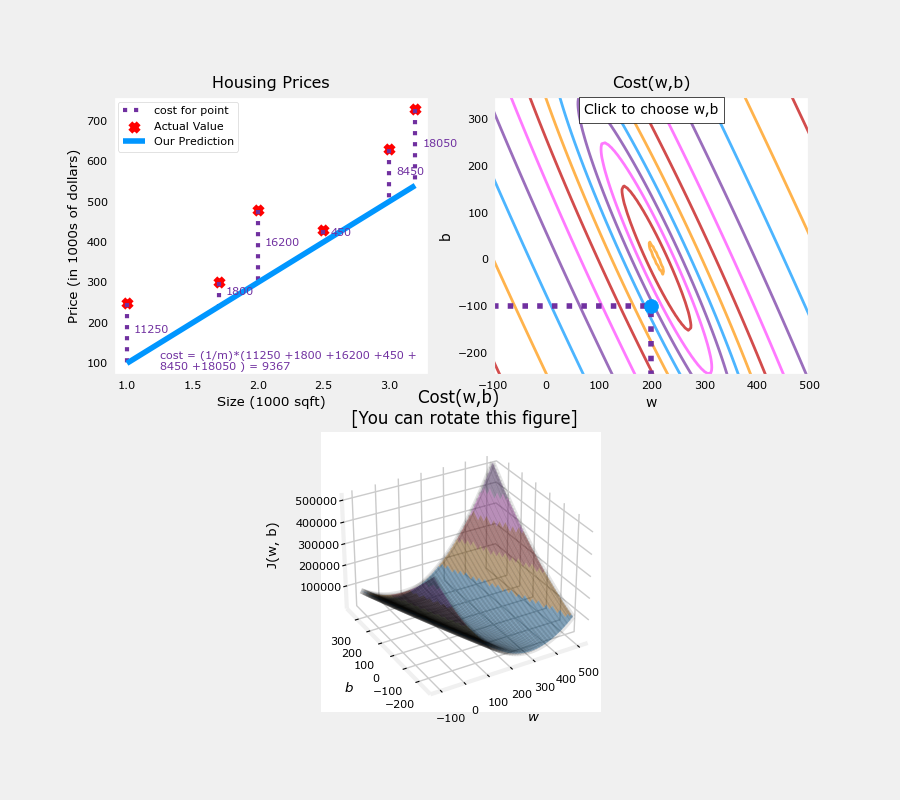

In [6]:
plt.close('all') 
fig, ax, dyn_items = plt_stationary(x_train, y_train)
updater = plt_update_onclick(fig, ax, x_train, y_train, dyn_items)

上文提到，请注意左图中的虚线。这些虚线代表训练集中每个样本对成本的贡献部分。在这种情况下，大约$w = 209$和$b = 2.4$的值会产生较低的成本。请注意，由于我们的训练样本不在一条直线上，所以最小成本不是零。

### 凸成本曲面
成本函数对损失进行平方运算这一事实确保了“误差曲面”像汤碗一样是凸面的。它总是有一个最小值，可以通过在所有维度上遵循梯度来达到。在上图中，由于$w$和$b$的维度比例不同，这一点不容易识别。下面这个$w$和$b$对称的图在讲座中展示过：

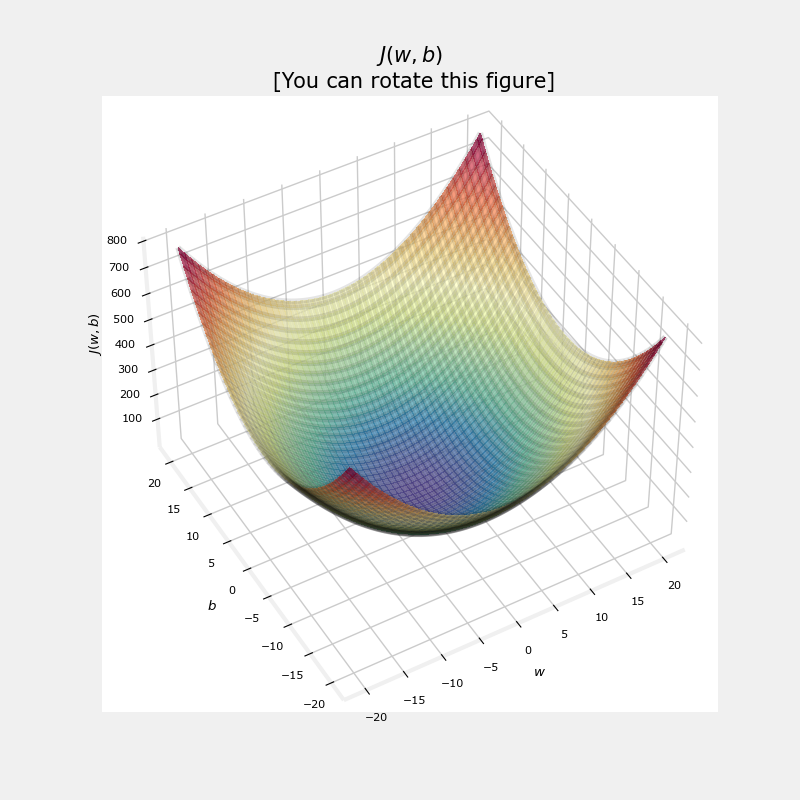

In [7]:
soup_bowl()

# 恭喜！!
你已经学到了以下内容：
成本方程衡量了你的预测与训练数据的匹配程度。
- 最小化成本可以提供$w$、$b$的最优值。